# Lab: Anomaly Detection

In [1]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

%config InlineBackend.figure_formats = {'png', 'retina'}

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from scipy import stats
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as stm
import statsmodels.api as sm
from platform import python_version

print("Python version", python_version())
print("NumPy version", np.__version__)
print("SciPy version", sp.__version__)
print("Pandas version", pd.__version__)
print("Matplotlib version", mpl.__version__)
print("Seaborn version", sns.__version__)
print("Statsmodels version", stm.__version__)

plt.style.use("seaborn-v0_8-muted")
plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["grid.linestyle"] = ':'
plt.rcParams["axes.grid"] = False

sns.set_style("whitegrid", {'axes.grid': False})


Python version 3.12.12
NumPy version 2.0.2
SciPy version 1.16.3
Pandas version 2.2.2
Matplotlib version 3.10.0
Seaborn version 0.13.2
Statsmodels version 0.14.5


In [2]:
from pathlib import Path

WORKDIR = Path.cwd()
DATA_DIR = WORKDIR
RANDOM_STATE = 42

pd.options.display.float_format = "{:,.4f}".format
sns.set_context("notebook", font_scale=1.1)

print("Working directory:", WORKDIR)


Working directory: /content


In [3]:
def log_transform(df, columns):
    """Apply log1p to selected columns."""
    result = df.copy()
    for column in columns:
        if column not in result:
            raise KeyError(f"{column} not found in dataframe")
        result[f"{column}_log"] = np.log1p(result[column])
    return result


# <font color='darkorange'>Part I: MHD for multivariate outlier detection</font>

From the diamond dataset (sheet 'Diamond' in anomaly-detection.xlsx), use the columns `carat`, `depth`, and ￼`price`   
to determine unususal diamonds from the dataset based on the MHD at 1% threshold.

**Mahalanobis distance** (MHD) measures the distance of transformed data point from the "centroid" of the dataset taking the covariance of variables into account. <br>
The Mahalanobis distance of point $\mathbf{x} \in R^k$ in the dataset with mean vector $\mathbf{\mu}$ and covariance matrix $\mathbf{\Sigma}$ is given by  <br><br>
\begin{equation}
 M(\mathbf{x}) = \sqrt{(\mathbf{x}-\mathbf{\mu})^T \mathbf{\Sigma}^{-1}(\mathbf{x}-\mathbf{\mu})}
\end{equation}
Basically, the point with higher Mahalanobis distance than typical points in the dataset could be the sign for outliers. <br>
So, the distance is used as the outlier score of data points.



For multivariate normal data, the squared MHD is $\chi^2(k)$.  So, the critical value at small $\alpha$, e.g. 0.001 can be used to flag anomalies.

**Define the MHD function**

Write a function that computes and returns the MHD for a given datapoint $x$, the mean vector $\mu$ (centroid) and the covariance matrix.

```
def MHD(x, mu, cov_mat):
    ...
    ...
```

In [4]:
def MHD(x, mu, cov_mat):
    """Return the Mahalanobis distance for a single point."""
    x = np.asarray(x, dtype=float)
    mu = np.asarray(mu, dtype=float)
    cov_mat = np.asarray(cov_mat, dtype=float)

    if cov_mat.ndim != 2 or cov_mat.shape[0] != cov_mat.shape[1]:
        raise ValueError("cov_mat must be a square matrix")

    diff = x - mu
    inv_cov = np.linalg.inv(cov_mat)
    return np.sqrt(np.dot(diff, np.dot(inv_cov, diff)))


**Load and explore the dataset**

Check the histograms and fix the skewed columns.

In [5]:
diamond = pd.read_excel("anomaly-detection.xlsx", sheet_name="Diamond")
diamond = diamond[["carat", "depth", "price"]].dropna().reset_index(drop=True)
diamond.head()
diamond.describe()


,carat,depth,price
0,0.2300,61.5000,326
1,0.2100,59.8000,326
2,0.2300,56.9000,327
3,0.2900,62.4000,334
4,0.3100,63.3000,335


,carat,depth,price
count,"53,940.0000","53,940.0000","53,940.0000"
mean,0.7979,61.7494,"3,932.7997"
std,0.4740,1.4326,"3,989.4397"
min,0.2000,43.0000,326.0000
25%,0.4000,61.0000,950.0000
50%,0.7000,61.8000,"2,401.0000"
75%,1.0400,62.5000,"5,324.2500"
max,5.0100,79.0000,"18,823.0000"


<Axes: xlabel='carat', ylabel='Density'>

Text(0.5, 1.0, 'Original carat')

<Axes: xlabel='depth', ylabel='Density'>

Text(0.5, 1.0, 'Original depth')

<Axes: xlabel='price', ylabel='Density'>

Text(0.5, 1.0, 'Original price')

Text(0.5, 0.98, 'Raw feature distributions')

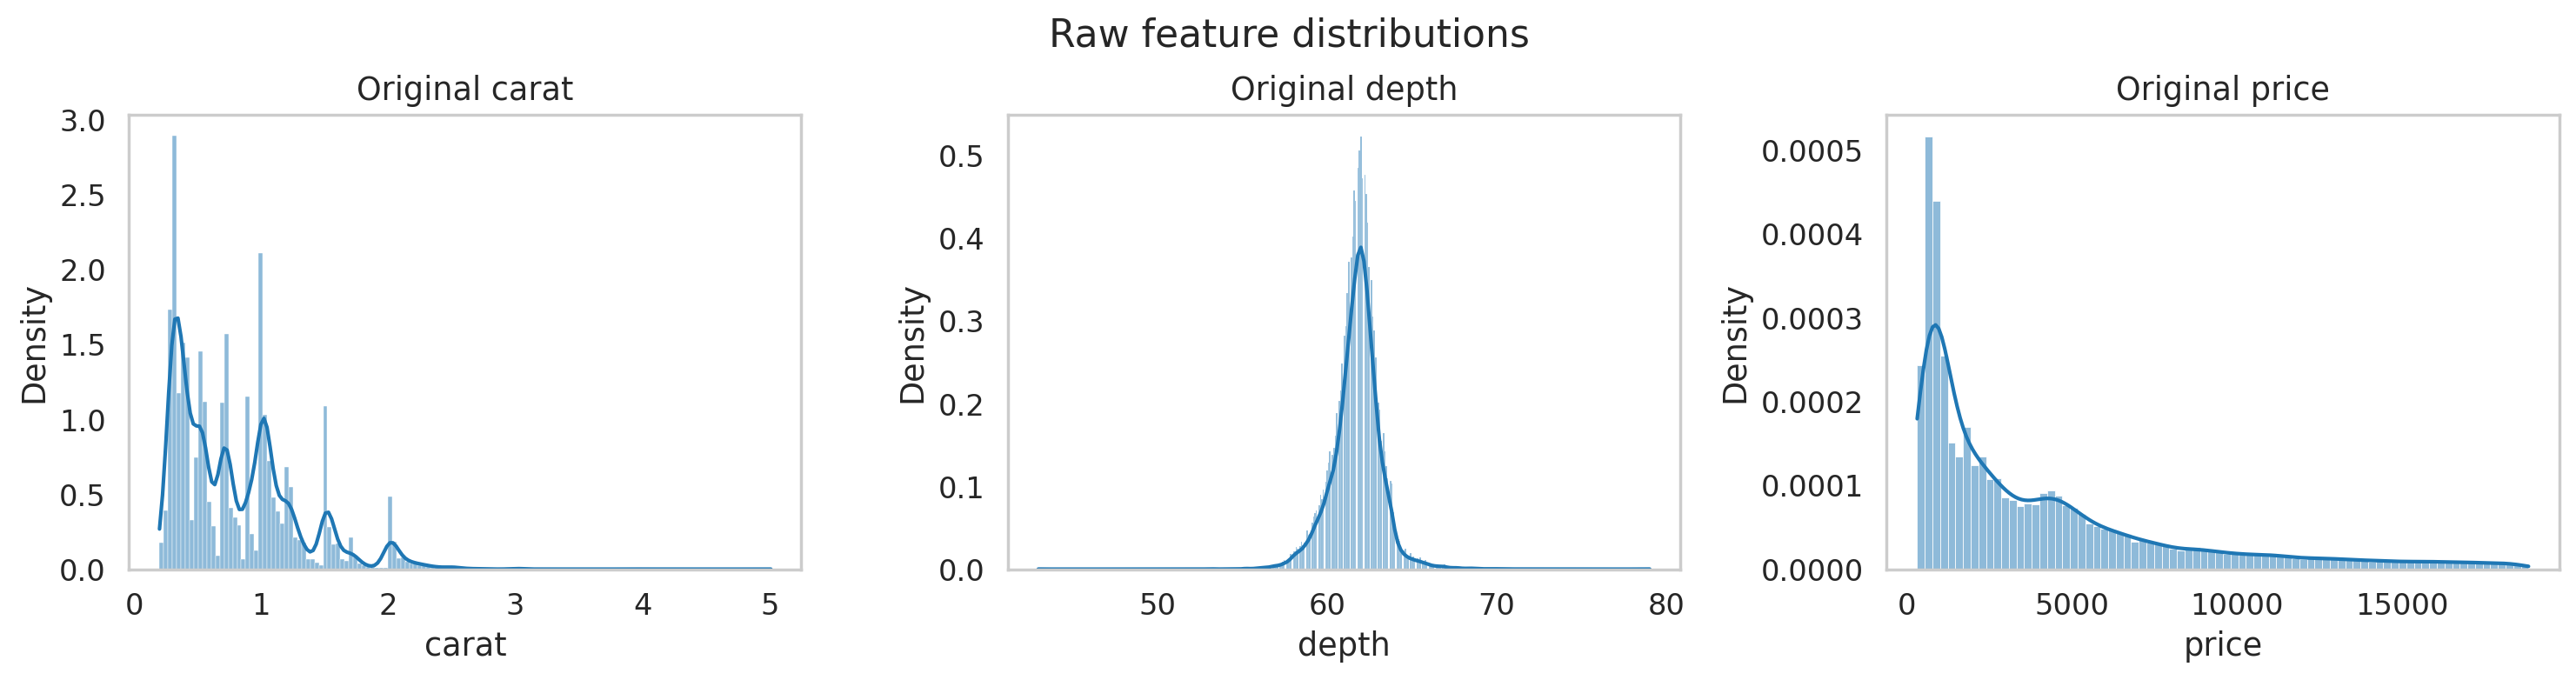

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column in zip(axes, diamond.columns):
    sns.histplot(diamond[column], kde=True, ax=ax, stat="density", color="tab:blue")
    ax.set_title(f"Original {column}")
fig.suptitle("Raw feature distributions")
fig.tight_layout()
fig.subplots_adjust(top=0.84)


<Axes: xlabel='carat_log', ylabel='Density'>

Text(0.5, 1.0, 'Transformed carat_log')

<Axes: xlabel='depth', ylabel='Density'>

Text(0.5, 1.0, 'Transformed depth')

<Axes: xlabel='price_log', ylabel='Density'>

...

Text(0.5, 0.98, 'Distributions after log transform')

<Figure size 400x300 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation (logged features)')

,carat_log,depth,price_log
count,"53,940.0000","53,940.0000","53,940.0000"
mean,0.5553,61.7494,7.7874
std,0.2449,1.4326,1.0141
min,0.1823,43.0000,5.7900
25%,0.3365,61.0000,6.8575
50%,0.5306,61.8000,7.7841
75%,0.7129,62.5000,8.5802
max,1.7934,79.0000,9.8429


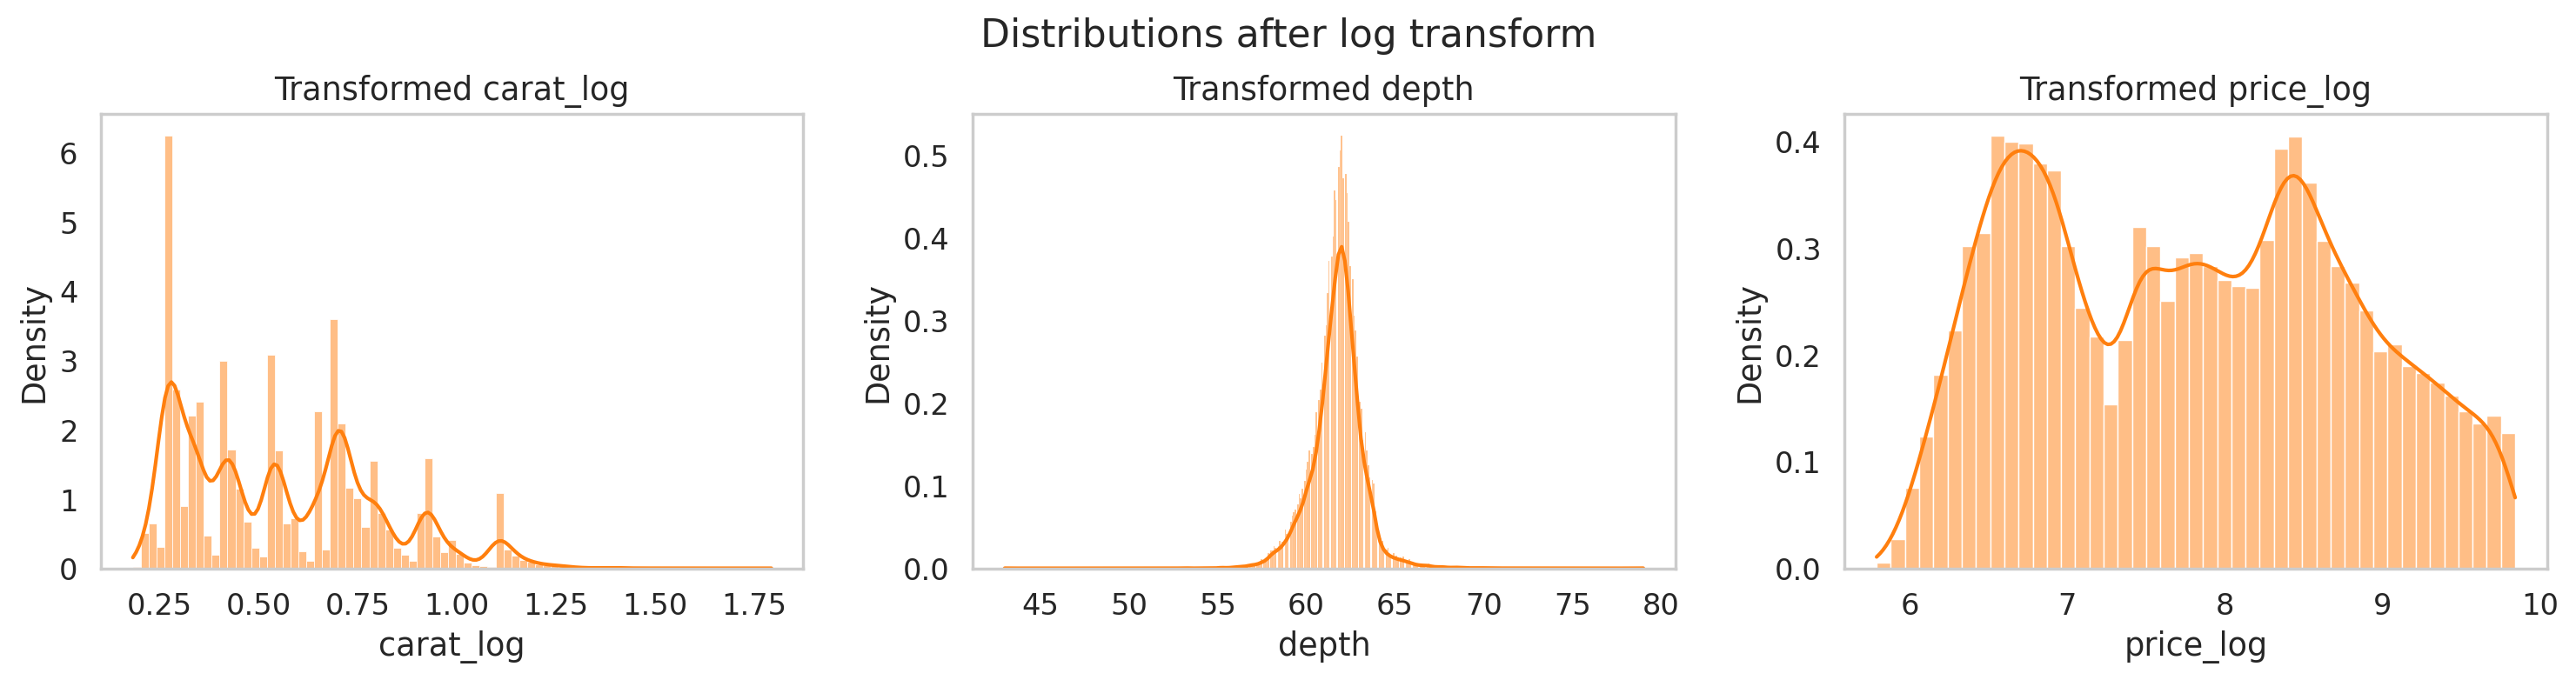

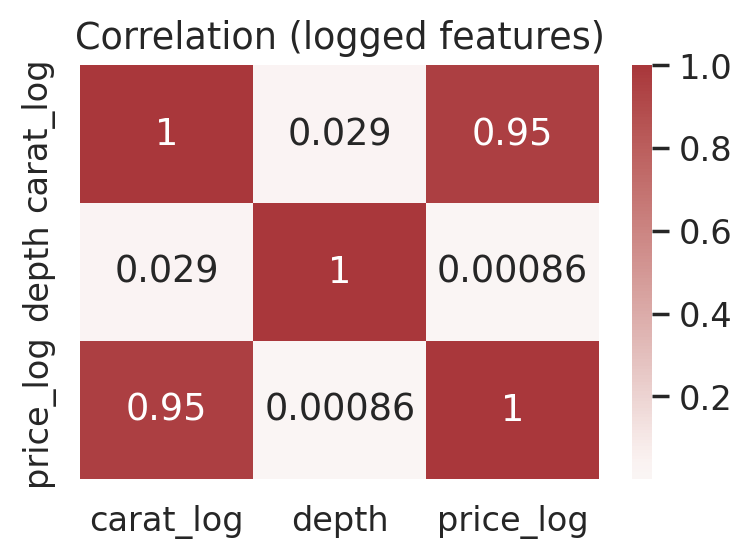

In [7]:
diamond_features = diamond.copy()
diamond_features = log_transform(diamond_features, ["carat", "price"])
diamond_features = diamond_features[["carat_log", "depth", "price_log"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column in zip(axes, diamond_features.columns):
    sns.histplot(diamond_features[column], kde=True, ax=ax, stat="density", color="tab:orange")
    ax.set_title(f"Transformed {column}")
fig.suptitle("Distributions after log transform")
fig.tight_layout()
fig.subplots_adjust(top=0.84)

plt.figure(figsize=(4, 3))
sns.heatmap(diamond_features.corr(), annot=True, cmap="vlag", center=0)
plt.title("Correlation (logged features)")
plt.tight_layout()

diamond_features.describe()


**Determine covariance matrix and centroid of the input data**

In [8]:
feature_cols = diamond_features.columns
mu = diamond_features.mean()
cov_mat = np.cov(diamond_features, rowvar=False)
cov_df = pd.DataFrame(cov_mat, index=feature_cols, columns=feature_cols)

print("Centroid (mean vector):")
display(mu.to_frame(name="mean"))
print("\nCovariance matrix:")
cov_df


Centroid (mean vector):


,mean
carat_log,0.5553
depth,61.7494
price_log,7.7874



Covariance matrix:


,carat_log,depth,price_log
carat_log,0.0600,0.0103,0.2368
depth,0.0103,2.0524,0.0012
price_log,0.2368,0.0012,1.0284


**Compute the squared MHD**

Determine the squared MHD of all datapoints and save them as a new column.  
Then, plot the histogram of the squared MHD.  

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='squared_mhd', ylabel='Density'>

Text(0.5, 1.0, 'Squared Mahalanobis distance (transformed features)')

Text(0.5, 0, 'Squared MHD')

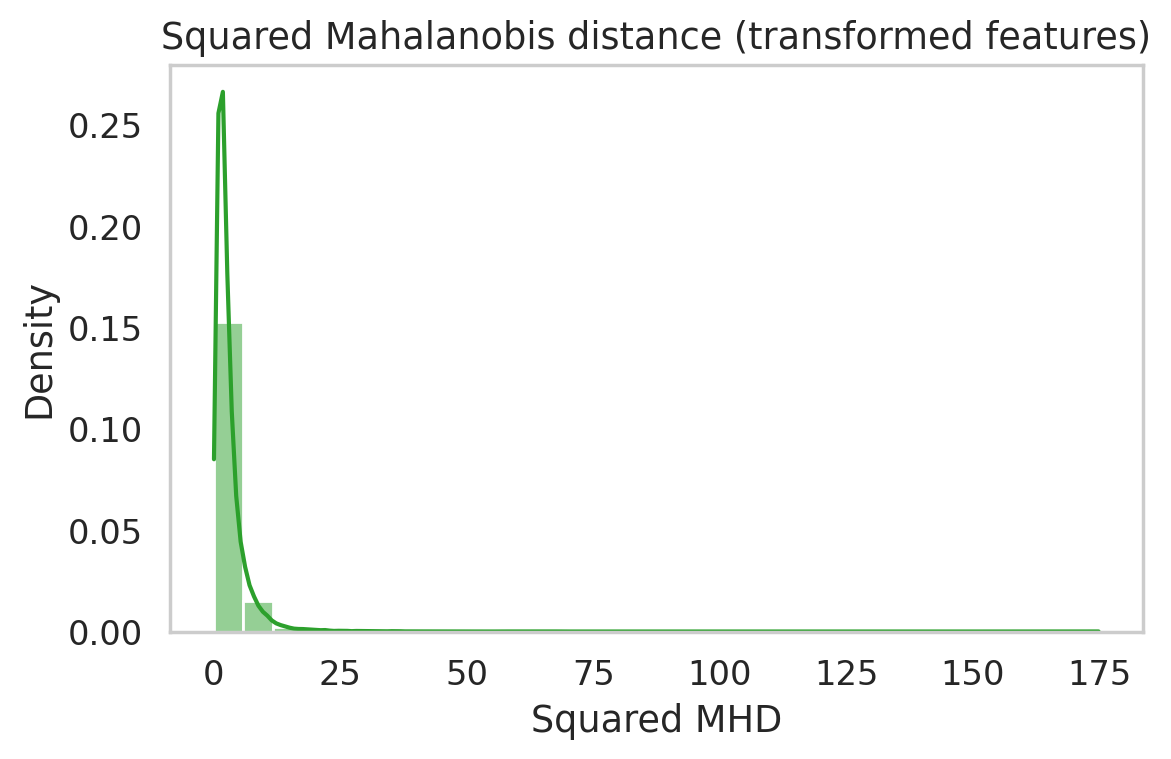

In [9]:
inv_cov = np.linalg.inv(cov_mat)
diamond["squared_mhd"] = diamond_features.apply(
    lambda row: np.dot(np.dot(row - mu, inv_cov), row - mu), axis=1
)

plt.figure(figsize=(6, 4))
sns.histplot(diamond["squared_mhd"], bins=30, kde=True, stat="density", color="tab:green")
plt.title("Squared Mahalanobis distance (transformed features)")
plt.xlabel("Squared MHD")
plt.tight_layout()


**Set the outlier threshold**

If the data is approximately multivariate normal, the squared Mahalanobis distance is  
approximately chi-square distribution with df = # of variables.
So, let's set the outlier threshold to the critical value at $\alpha=0.001$.

In [10]:
df = len(feature_cols)
mhd_threshold = stats.chi2.ppf(0.999, df)
print(f"Chi-square threshold (df={df}, alpha=0.001): {mhd_threshold:.3f}")
diamond["is_outlier"] = diamond["squared_mhd"] > mhd_threshold


Chi-square threshold (df=3, alpha=0.001): 16.266


**Print rows in the dataset identified as outliers**

How many rows are identified as outliers?

In [11]:
outliers = diamond[diamond["is_outlier"]].copy()
print("Number of outliers:", len(outliers))
outliers


Number of outliers: 570


,carat,depth,price,squared_mhd,is_outlier
2,0.2300,56.9000,327,18.6700,True
91,0.8600,55.1000,2757,22.3868,True
204,0.9800,67.9000,2777,19.2334,True
227,0.8400,55.1000,2782,22.1014,True
298,1.0100,67.4000,2797,16.7884,True
...,...,...,...,...,...
53540,0.9000,72.9000,2691,60.5990,True
53542,0.7800,54.7000,2691,24.3956,True
53756,0.8400,55.6000,2724,19.0267,True
53757,0.7200,55.4000,2724,19.6778,True


# <font color='darkorange'>Part II: Latent-variable based Anomaly detection</font>

The bearing dataset (`BearingTest.csv`) contains the time series data from four sensors.
- Use data from '2004-02-12 11:02:39' to '2004-02-13 23:52:39' as the train data and from '2004-02-13 23:52:39' as the test data.
- Apply PCA with two PCs to the training data to obtain the latent-variable model.
- Plot the histogram of mean absolute error (MAE) from reconstruction errors of individual training data points and set the anomaly threshold to 105% of the maximum MAE.  
- Visualize the MAE of train data and test data over time and identify the time when the model detects anomalies.

## Data preprocessing

**Load the data set**

In [12]:
bearing = pd.read_csv("BearingTest.csv", index_col=0, parse_dates=True)
bearing = bearing.sort_index()
bearing.head()


,Bearing 1,Bearing 2,Bearing 3,Bearing 4
2004-02-12 10:32:39,0.0583,0.0718,0.0832,0.0431
2004-02-12 10:42:39,0.0590,0.0740,0.0844,0.0445
2004-02-12 10:52:39,0.0602,0.0742,0.0839,0.0444
2004-02-12 11:02:39,0.0615,0.0738,0.0845,0.0451
2004-02-12 11:12:39,0.0614,0.0756,0.0828,0.0451


**Split the data into train and test sets, and plot them**

In [13]:
train_start = pd.to_datetime("2004-02-12 11:02:39")
train_end = pd.to_datetime("2004-02-13 23:52:39")

train = bearing.loc[train_start:train_end].copy()
test = bearing.loc[train_end:].copy()

print("Train range:", train.index[0], "to", train.index[-1])
print("Test range:", test.index[0], "to", test.index[-1])
train.shape, test.shape


Train range: 2004-02-12 11:02:39 to 2004-02-13 23:52:39
Test range: 2004-02-13 23:52:39 to 2004-02-19 06:22:39


((222, 4), (760, 4))

<Axes: >

<Axes: >

Text(0.5, 1.0, 'Bearing sensor readings (vibration magnitude)')

Text(0, 0.5, 'Vibration')

Text(0.5, 0, 'Time')

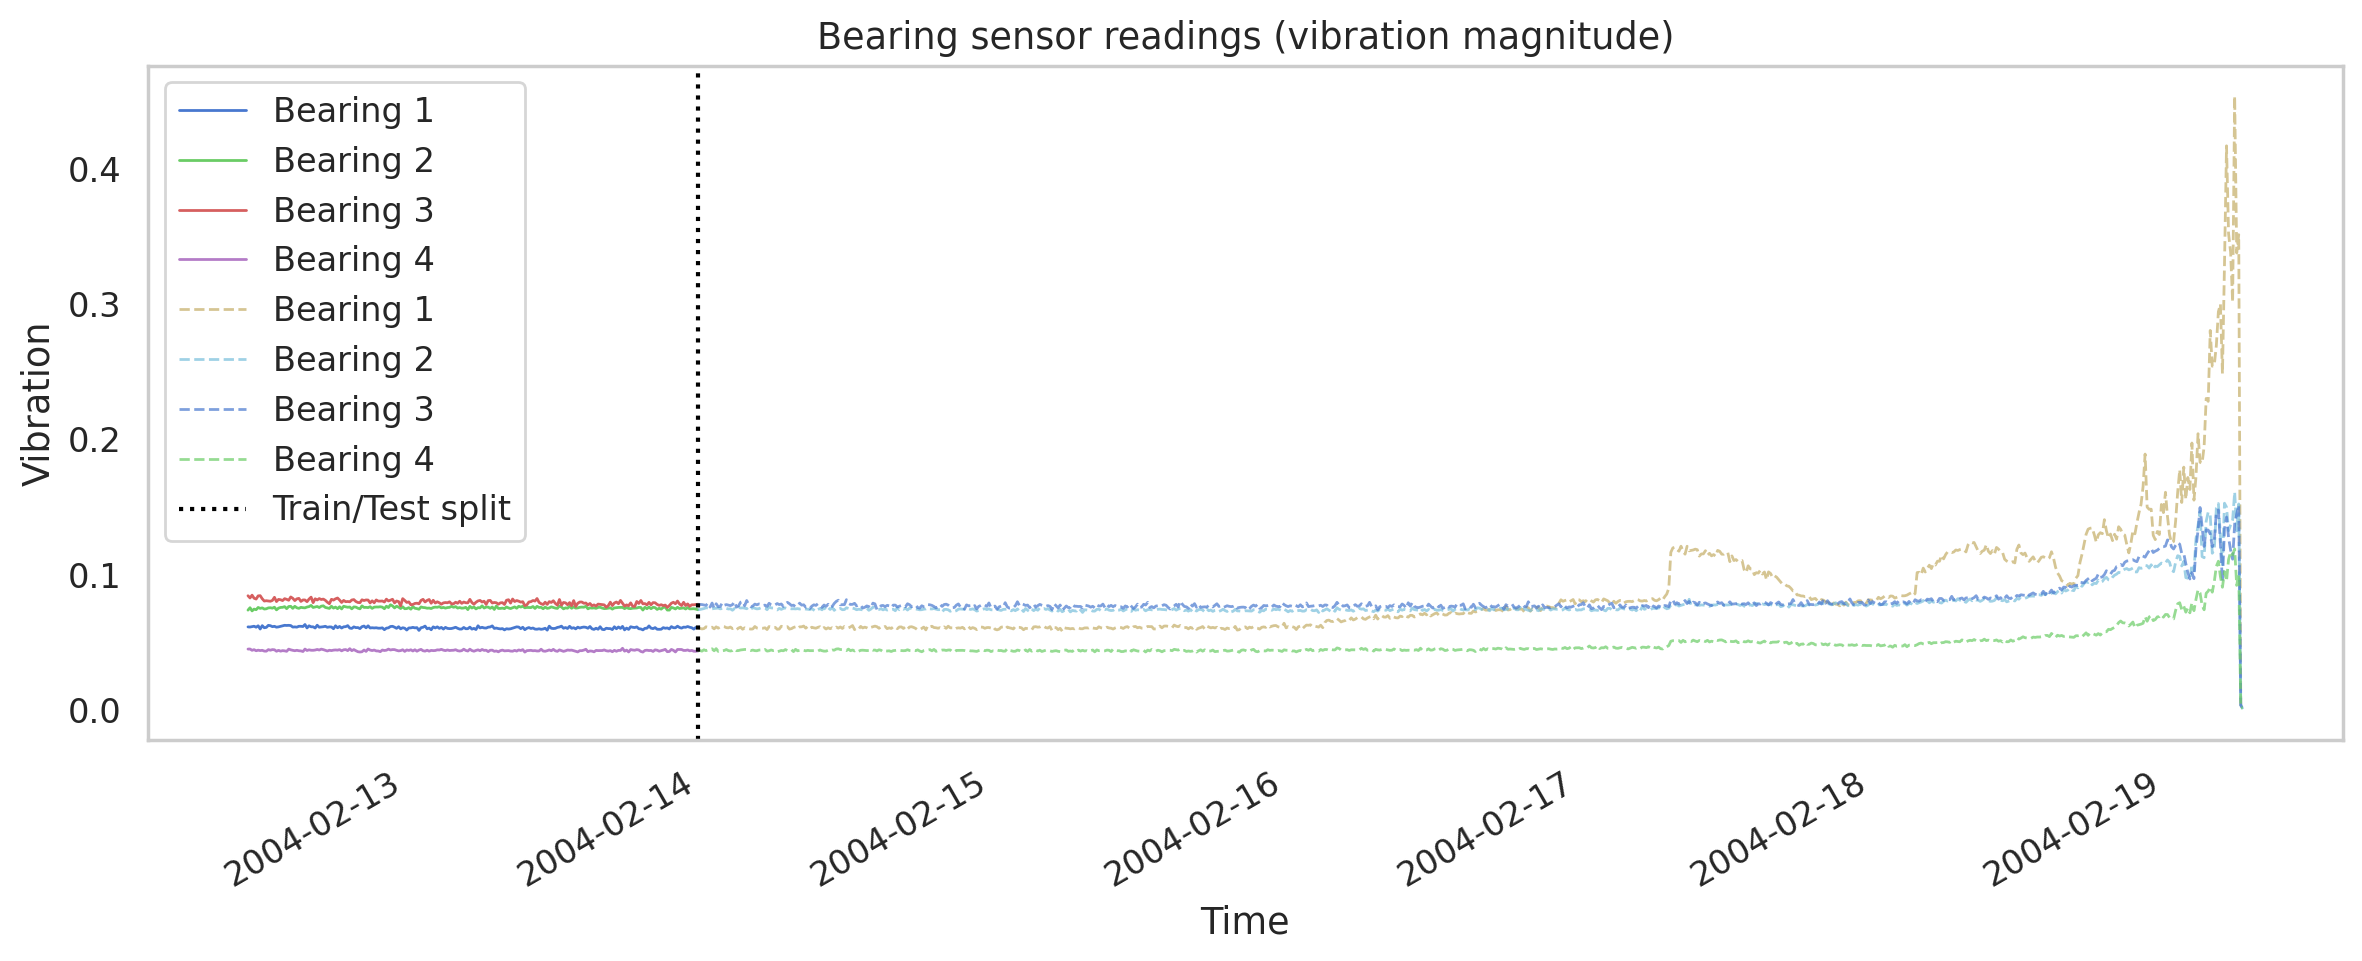

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
train.plot(ax=ax, lw=1)
test.plot(ax=ax, lw=1, linestyle="--", alpha=0.7)
ax.axvline(train_end, color="k", linestyle=":", label="Train/Test split")
ax.set_title("Bearing sensor readings (vibration magnitude)")
ax.set_ylabel("Vibration")
ax.set_xlabel("Time")
ax.legend(loc="upper left")
plt.tight_layout()


**Standardize the train set and apply the scaler to the test set**

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_scaled = pd.DataFrame(
    scaler.fit_transform(train), index=train.index, columns=train.columns
)
test_scaled = pd.DataFrame(
    scaler.transform(test), index=test.index, columns=test.columns
)

train_scaled.head()


,Bearing 1,Bearing 2,Bearing 3,Bearing 4
2004-02-12 11:02:39,0.7045,-2.4816,2.6776,1.9352
2004-02-12 11:12:39,0.5907,0.0057,1.7443,2.0056
2004-02-12 11:22:39,0.9563,-3.2786,2.9205,0.2043
2004-02-12 11:32:39,1.2918,-1.4261,1.6231,1.1302
2004-02-12 11:42:39,0.4341,-2.0200,1.2750,-0.4281


## PCA Model Construction

**Apply PCA with two components to the train data to obtain the train PC scores**

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
train_pca = pd.DataFrame(
    pca.fit_transform(train_scaled), index=train_scaled.index, columns=["PC1", "PC2"]
)
train_pca.head()


,PC1,PC2
2004-02-12 11:02:39,1.4717,1.7161
2004-02-12 11:12:39,2.1483,0.0522
2004-02-12 11:22:39,0.5424,3.3044
2004-02-12 11:32:39,1.3839,1.2839
2004-02-12 11:42:39,-0.2754,1.9965


**Use the PCA model to transform the test data to obtain the test PC scores**

In [17]:
test_pca = pd.DataFrame(
    pca.transform(test_scaled), index=test_scaled.index, columns=["PC1", "PC2"]
)
test_pca.head()


,PC1,PC2
2004-02-13 23:52:39,-1.7144,0.7363
2004-02-14 00:02:39,-1.6895,-0.0166
2004-02-14 00:12:39,-2.2084,0.1237
2004-02-14 00:22:39,-1.0547,-1.2266
2004-02-14 00:32:39,-0.4559,-0.4614


## Anomaly Detection with MHD

**Determine squared MHD of train PC scores**

In [18]:
pca_mean = train_pca[["PC1", "PC2"]].mean()
pca_cov = np.cov(train_pca[["PC1", "PC2"]], rowvar=False)
inv_pca_cov = np.linalg.inv(pca_cov)

train_pca["squared_mhd"] = train_pca[["PC1", "PC2"]].apply(
    lambda row: np.dot(np.dot(row - pca_mean, inv_pca_cov), row - pca_mean), axis=1
)
train_pca.head()


,PC1,PC2,squared_mhd
2004-02-12 11:02:39,1.4717,1.7161,4.8382
2004-02-12 11:12:39,2.1483,0.0522,2.3070
2004-02-12 11:22:39,0.5424,3.3044,14.0776
2004-02-12 11:32:39,1.3839,1.2839,3.0589
2004-02-12 11:42:39,-0.2754,1.9965,5.1234


**Visualize the histogram of squared MHD of the train PC scores**

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='squared_mhd', ylabel='Density'>

Text(0.5, 1.0, 'Squared MHD of PCA scores (train)')

Text(0.5, 0, 'Squared MHD')

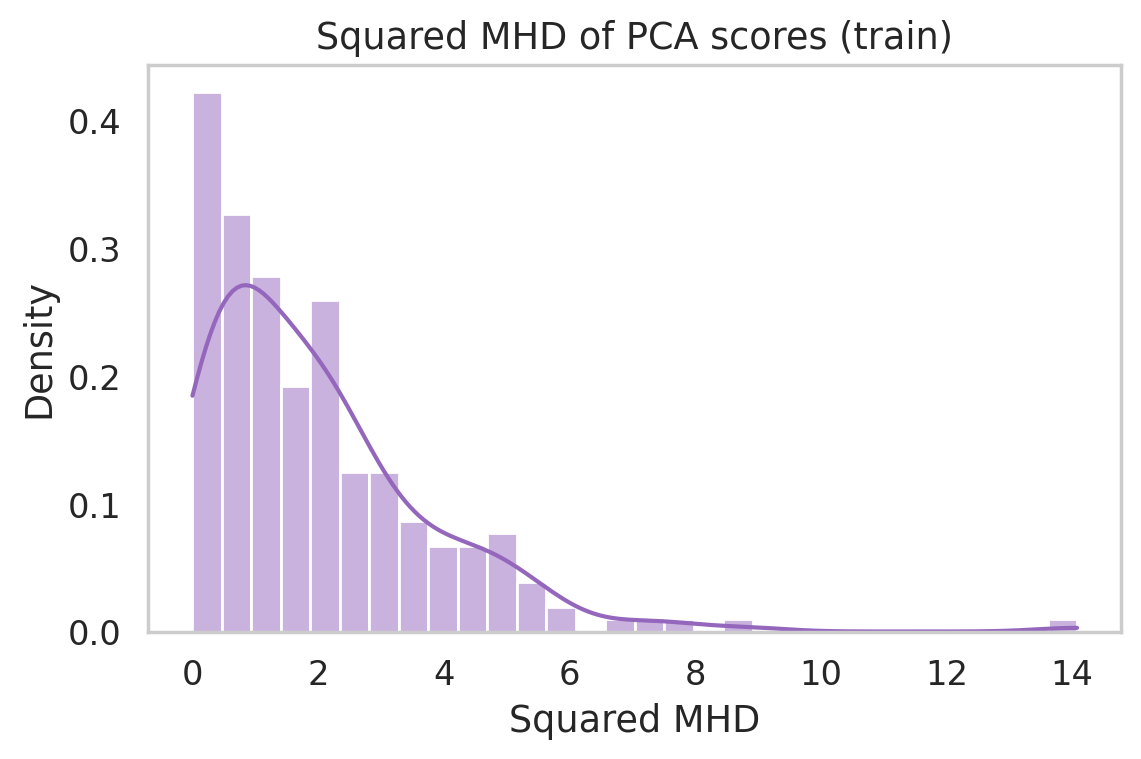

In [19]:
plt.figure(figsize=(6, 4))
sns.histplot(train_pca["squared_mhd"], bins=30, kde=True, stat="density", color="tab:purple")
plt.title("Squared MHD of PCA scores (train)")
plt.xlabel("Squared MHD")
plt.tight_layout()


**Set the outlier threshold**

If the data is approximately multivariate normal, the squared Mahalanobis distance will be  
approximately $\chi^2$ with df = # of variables. Let's use the critical value at 0.001 as the outlier threshold.

In [20]:
pca_df = train_pca[["PC1", "PC2"]].shape[1]
mhd_threshold = stats.chi2.ppf(0.999, pca_df)
print(f"PCA squared MHD threshold (df={pca_df}, alpha=0.001): {mhd_threshold:.3f}")


PCA squared MHD threshold (df=2, alpha=0.001): 13.816


**Determine squared MHD of test PC scores**

In [21]:
test_pca["squared_mhd"] = test_pca[["PC1", "PC2"]].apply(
    lambda row: np.dot(np.dot(row - pca_mean, inv_pca_cov), row - pca_mean), axis=1
)
test_pca.head()


,PC1,PC2,squared_mhd
2004-02-13 23:52:39,-1.7144,0.7363,2.1587
2004-02-14 00:02:39,-1.6895,-0.0166,1.4251
2004-02-14 00:12:39,-2.2084,0.1237,2.4538
2004-02-14 00:22:39,-1.0547,-1.2266,2.4748
2004-02-14 00:32:39,-0.4559,-0.4614,0.3754


**Visualize the squared MHD of train and test PC against the threshold**.

From the plot, approximately at what datetime the model detects the equipment failure?

Text(0.5, 1.0, 'Squared MHD of PCA scores over time')

Text(0, 0.5, 'Squared MHD')

Text(0.5, 0, 'Time')

PCA-based MHD anomaly detected at 2004-02-15 04:52:39


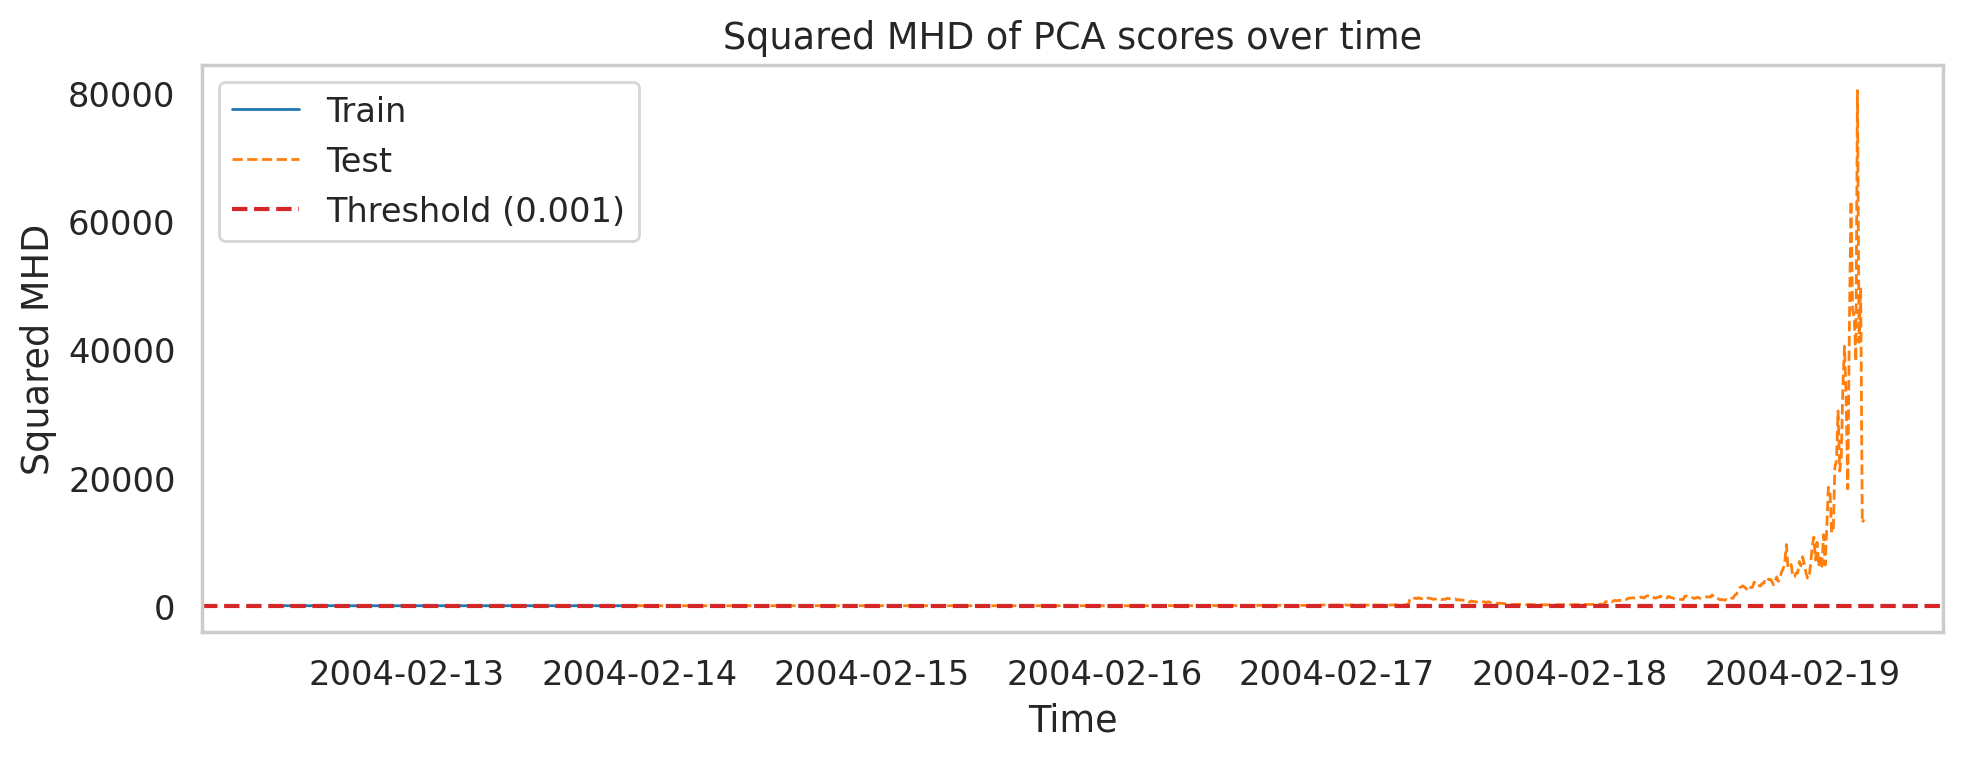

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_pca.index, train_pca["squared_mhd"], label="Train", color="tab:blue", lw=1)
ax.plot(test_pca.index, test_pca["squared_mhd"], label="Test", color="tab:orange", lw=1, linestyle="--")
ax.axhline(mhd_threshold, color="tab:red", linestyle="--", label="Threshold (0.001)")
ax.set_title("Squared MHD of PCA scores over time")
ax.set_ylabel("Squared MHD")
ax.set_xlabel("Time")
ax.legend()
plt.tight_layout()

pca_outliers = test_pca[test_pca["squared_mhd"] > mhd_threshold]
if not pca_outliers.empty:
    print("PCA-based MHD anomaly detected at", pca_outliers.index[0])
else:
    print("No PCA-based MHD anomalies detected in the test window.")


## Anomaly Detection with Reconstruction Errors

In this approach, the inversed transform of PC scores are compared to the original data and the reconstruction errors are determined.  
The Mean Absolute Error (MAE) metric will be used to measure the reconstruction errors, which are the outlier scores of data points.  
The outlier threshold is derived based on the MAE of train data.   

Determine the inverse-transform of the train PC scores.
Then, compute the MAE of the reconstructed data and the train data.

In [23]:

train_reconstructed = pd.DataFrame(
    pca.inverse_transform(train_pca[["PC1", "PC2"]]),
    index=train_scaled.index,
    columns=train_scaled.columns,
)
# Align with raw numpy arrays so pandas alignment gaps do not turn into NaNs.
train_mae = pd.Series(
    np.abs(train_scaled.values - train_reconstructed.values).mean(axis=1),
    index=train_scaled.index,
    name="MAE",
)
train_mae.head()


,0
2004-02-12 11:02:39,NaN
2004-02-12 11:12:39,NaN
2004-02-12 11:22:39,NaN
2004-02-12 11:32:39,NaN
2004-02-12 11:42:39,NaN


Plot the MAE of the reconstructed data and the train data.

<Figure size 1000x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Mean absolute reconstruction error (train)')

Text(0, 0.5, 'MAE (standardized)')

Text(0.5, 0, 'Time')

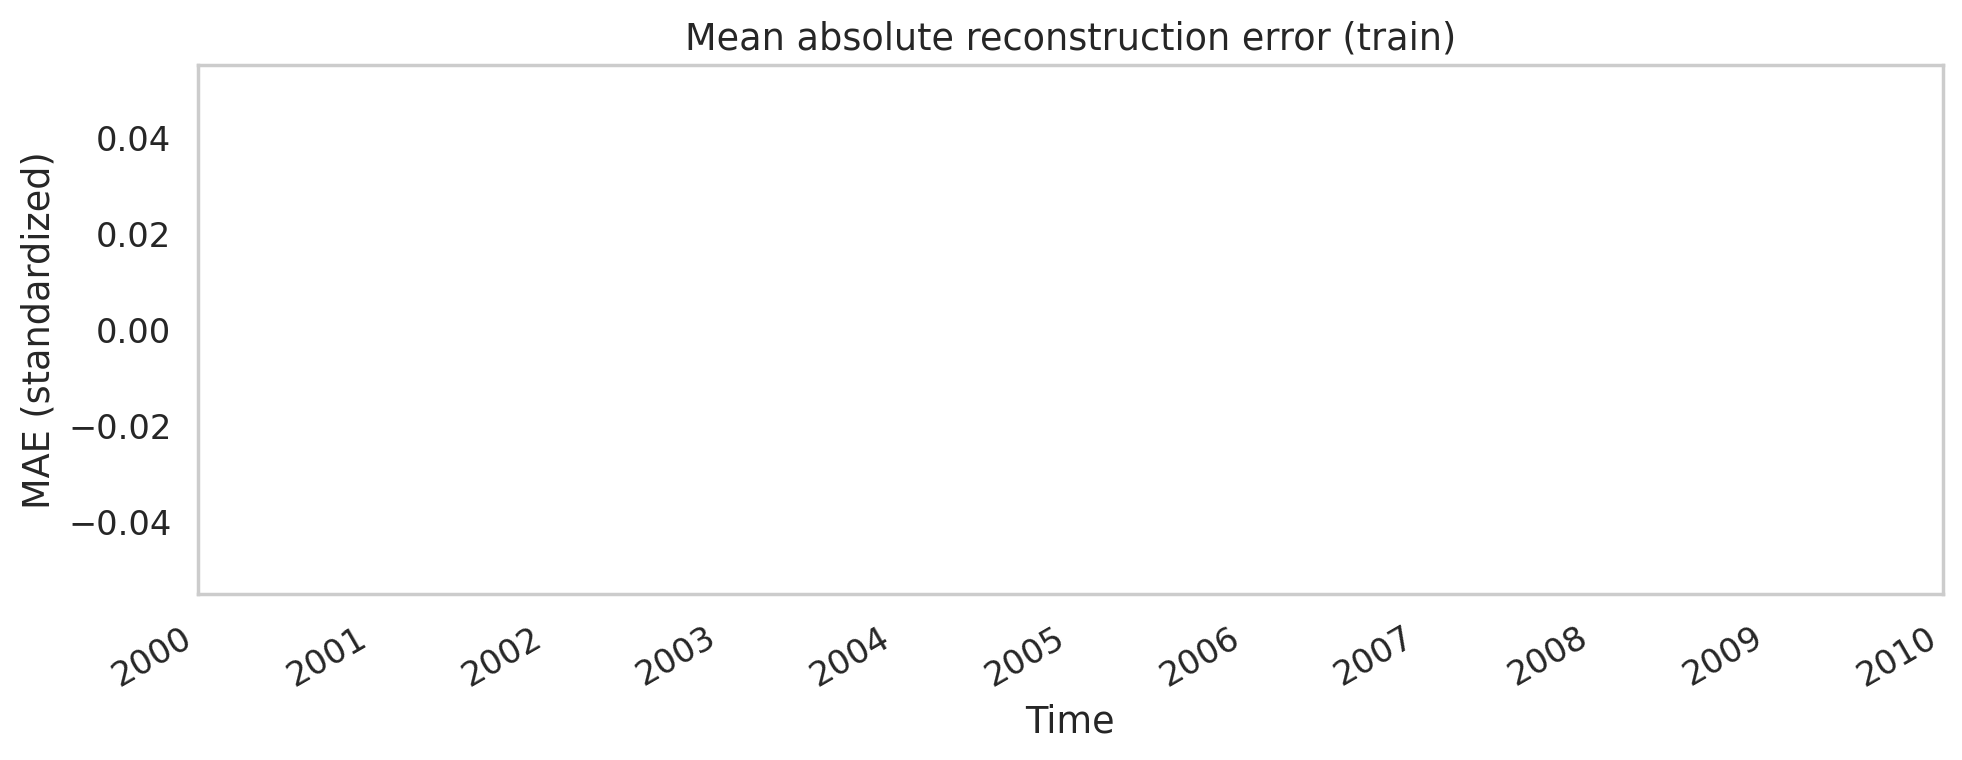

In [24]:
plt.figure(figsize=(10, 4))
train_mae.plot(label="Train MAE")
plt.title("Mean absolute reconstruction error (train)")
plt.ylabel("MAE (standardized)")
plt.xlabel("Time")
plt.tight_layout()


Set the outlier threshold as 110% of the maximum MAE.

In [25]:
mae_threshold = 1.1 * train_mae.max()
print("Reconstruction MAE threshold (110% of max train MAE):", mae_threshold)


Reconstruction MAE threshold (110% of max train MAE): nan


**Determine the MAE of test PC data**

In [26]:

test_reconstructed = pd.DataFrame(
    pca.inverse_transform(test_pca[["PC1", "PC2"]]),
    index=test_scaled.index,
    columns=test_scaled.columns,
)
# Align with raw numpy arrays so pandas alignment gaps do not turn into NaNs.
test_mae = pd.Series(
    np.abs(test_scaled.values - test_reconstructed.values).mean(axis=1),
    index=test_scaled.index,
    name="MAE",
)
test_mae.head()


,0
2004-02-13 23:52:39,NaN
2004-02-14 00:02:39,NaN
2004-02-14 00:12:39,NaN
2004-02-14 00:22:39,NaN
2004-02-14 00:32:39,NaN


**Visualize the MAE of train and test data against the threshold**.

From the plot, approximately at what datetime the model detects the equipment failure?

<Axes: >

<Axes: >

Text(0.5, 1.0, 'Reconstruction MAE over time')

Text(0, 0.5, 'MAE (standardized)')

Text(0.5, 0, 'Time')

No reconstruction MAE anomalies detected in the test window.


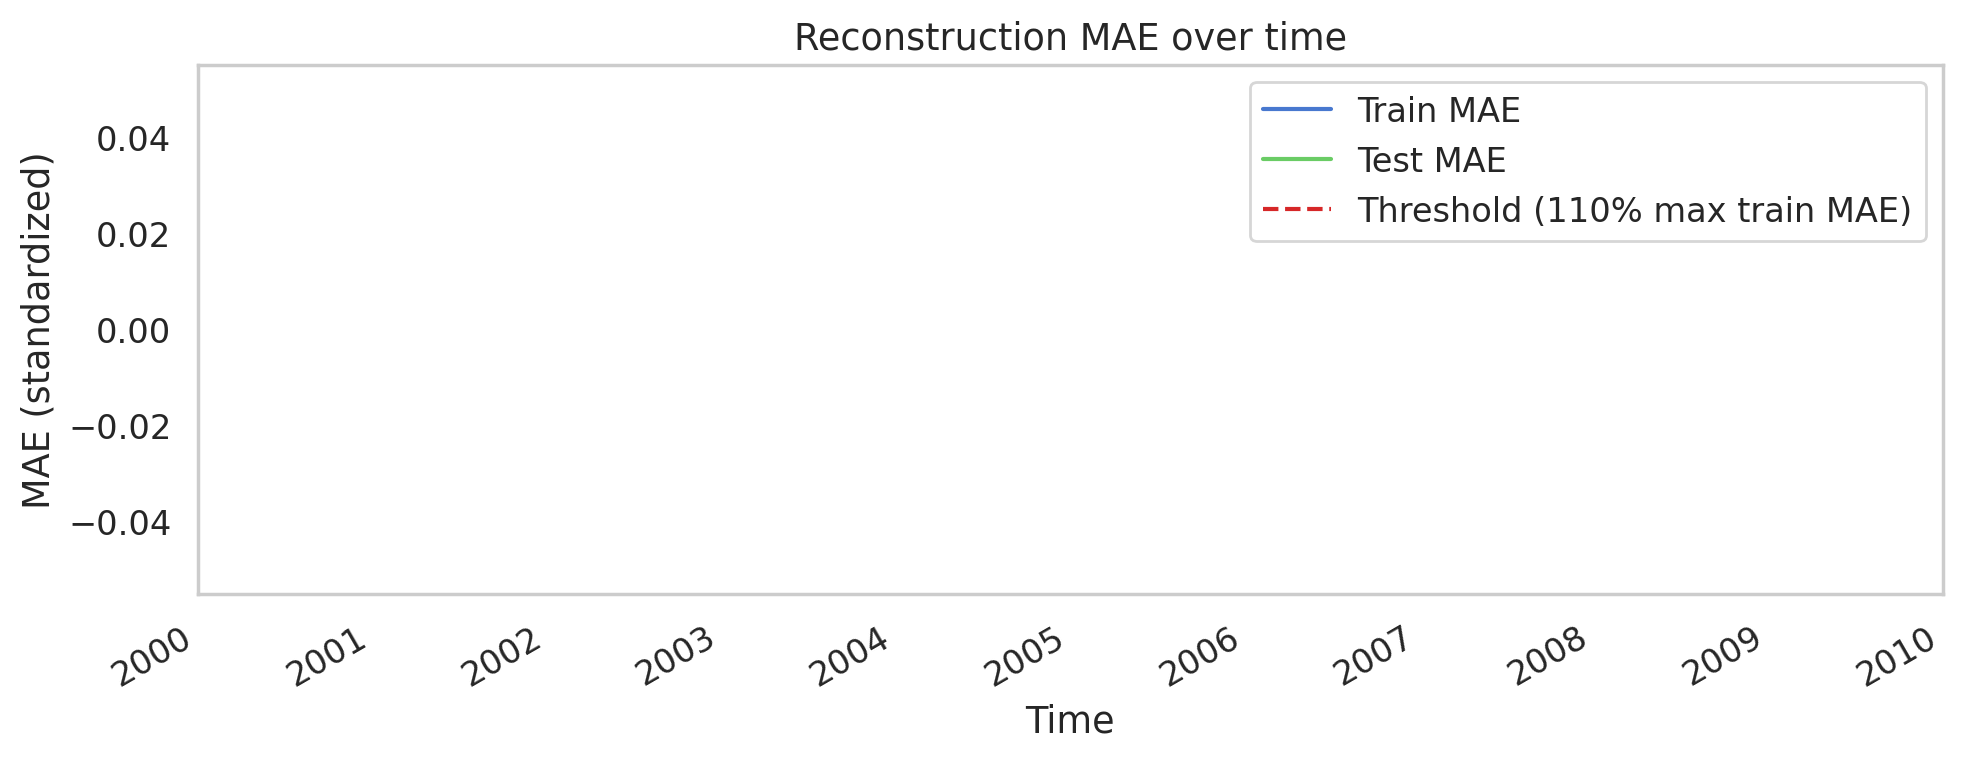

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
train_mae.plot(ax=ax, label="Train MAE")
test_mae.plot(ax=ax, label="Test MAE")
ax.axhline(mae_threshold, color="tab:red", linestyle="--", label="Threshold (110% max train MAE)")
ax.set_title("Reconstruction MAE over time")
ax.set_ylabel("MAE (standardized)")
ax.set_xlabel("Time")
ax.legend()
plt.tight_layout()

mae_outliers = test_mae[test_mae > mae_threshold]
if not mae_outliers.empty:
    print("Reconstruction MAE anomaly detected at", mae_outliers.index[0])
else:
    print("No reconstruction MAE anomalies detected in the test window.")
